# Neural Network creation for Pump-valves block data

***

**Author:** Juan M. Montes-Sánchez

**GitHub:** https://github.com/juamonsan

***

In this notebook you will find a step by step guide where you will:
- Load data taken with FP-SNS-DATALOG1 on a STEVAL-MKSBOX1V1FP-SNS-DATALOG and pre-processed as .csv files with "Dataset preparation" notebook from this same project
- Split the data into train, evaluation and test
- Generate and train a Neural Network capable of classifing lectures from the sensors
- Evaluate the Neural Network with test data
- Generating plots and metrics related to the data or the Neural Network

## Requirements

You **MUST** have:
- Data in .csv and with a proper folder structure created with "Dataset preparation" notebook from this same project

Optional requirements include:
- CUDA compatible Nvidia GPU

## Previous steps

### Neural Network environment: Importing Keras/Tensorflow

Import tensorflow and check if we have GPUs availables. If so, it means a GPU is ready to be used for tensorflow training.

In [1]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.utils import to_categorical

import sys

print("Python version {}.{}".format(sys.version_info.major, sys.version_info.minor))

print("Tensorflow version " + tf.__version__)

Python version 3.7
Tensorflow version 2.1.0


In [2]:
from tensorflow.python.client import device_lib

num_GPUs=len(tf.config.experimental.list_physical_devices('GPU'))

tf.config.list_physical_devices('GPU')

device_lib.list_local_devices()

tf.test.is_built_with_cuda()

tf.debugging.set_log_device_placement(True)


if(num_GPUs>0):
    print("Your system has {} GPUs availables".format(num_GPUs))
else:
    print("No GPUs available")    


Your system has 1 GPUs availables


---
If we have a Nvidia GPU with drivers and CUDA properly installed we can also get some extra information: GPU model, driver and CUDA versions, activity...

In [3]:
# GPU count and name
!nvidia-smi -L
# GPU activity
!nvidia-smi

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-235cadad-b6ee-9e16-4bcd-63bcc7b79e19)
Tue Jul  4 14:57:26 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.98                 Driver Version: 535.98       CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   52C    P0              13W /  50W |    158MiB /  4096MiB |      0%      Default |
|                                         |                      |            

---
### Other imports

In [4]:
# More imports
import matplotlib.pyplot as plt #for plotting raw data
import os #for system folders and files management
import pathlib #for system folders and files management
import pandas as pd #for Dataframe handling

from IPython.display import display # for folder selection dialog
from ipyfilechooser import FileChooser # for folder selection dialog

import numpy as np
import math
import csv

#for metrics and plots
import sklearn.model_selection
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import seaborn as sns #for plotting confusion matrix

# End

In [5]:
# Make numpy values easier to read (optional).
np.set_printoptions(precision=3, suppress=True)

### Definitions

In [6]:
# Plots a 3 axis data sample if given a .csv file
def plot_record(file_path, xName, yName):
    data = pd.read_csv(file_path, sep=',')
    data = data.to_numpy()
    print("Shape of the data is: {}".format(np.shape(data)))
    #plt.plot(data[:,0], data[:,1], #if we have a timestamp at column 0
    #         data[:,0], data[:,2],
    #         data[:,0], data[:,3])
    plt.plot(range(np.shape(data)[0]), data[:,0],
             range(np.shape(data)[0]), data[:,1],
             range(np.shape(data)[0]), data[:,2])
    plt.xlabel(xName)
    plt.ylabel(yName)
    #plt.xlim((0, 200))
    #plt.ylim((-1500, 1500))

## Loading data

### Loading from CSV



Select data folder and extract data size from the content of the files. We are going to consider the data is already in the desired format.

In [7]:
#Select sensor csv folder:

# Create and display a FileChooser widget
fc = FileChooser('./')
fc.show_only_dirs=True
print("--------------------------------\nSELECT TRAIN DATA SENSOR FOLDER\n--------------------------------")
display(fc)
print("--------------------------------\n")

--------------------------------
SELECT TRAIN DATA SENSOR FOLDER
--------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

--------------------------------



Number of samples: 1036
Sample size: 400
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 2
Shape of the data is: (399, 3)


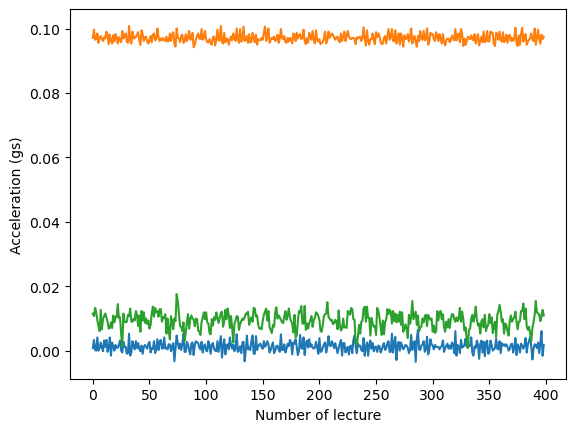

In [8]:
if fc.selected_path==None:
    csv_folder_path="TEST_DATA\\expData\\STBOX_00001_Windows" #Select desired path
    sensor_folder="ACC_LIS3DHH_1100Hz" #Select desired sensor folder
    full_path=os.path.join(csv_folder_path,sensor_folder)
else:
    full_path = fc.selected_path

Current_file_path = os.path.join(full_path,os.listdir(full_path)[0])

Current_file = open(Current_file_path) # Open first file for counting rows

num_samples= len(os.listdir(full_path)) #number of .csv files in total
tam_samples= len(Current_file.readlines())#number of lectures in a window sample (rows in each .csv)
num_features = 3 #axis number (3 for accel) TODO: read column number from the file

print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples,tam_samples,num_features))
print("-----------------------\nPlot example for first file:\n-----------------------")

file_class=int(Current_file_path[-6:-4])-1 # Class is in the filename, at the end, just before file extension
print("The class for this file is {}".format(file_class))

plot_record(Current_file_path, 'Number of lecture', 'Acceleration (gs)')

Current_file.close() # Close file

Using the variables from above cell, we create two training numpy arrays for feeding the NN: one contains the data (trainX) and the other the desired outputs in one hot format (trainY)

In [9]:
DataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
DataY=np.empty([num_samples])

for i in range (num_samples):
    Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
    Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
    DataX[i]=Current_CSV
    if np.any(np.isnan(DataX[i])):
        print(i)
        for k in range(0,len(DataX[i])):
            if np.any(np.isnan(DataX[i][k])):
                print("File {} in line {} is NaN".format(i,k))
    file_class=int(Current_file_path[-6:-4])
    DataY[i]=file_class-1 #first class is class 1, but now we start from 0
    #print("{} (Class {})".format(Current_file_path,file_class))
#    if file_class == 1:
#        DataY[i]='001'
#    elif file_class == 2:
#        DataY[i]='010'
#    elif file_class == 3:
#        DataY[i]='100'
#    else:
#        print("ERROR")
#        DataY[i]='000'

DataY = to_categorical(DataY)        
print("The shape of DataX array is: {}".format(np.shape(DataX))) # We check if the shape is correct
if np.any(np.isnan(DataX)):
    print("DANGER!! NaN values found in DataX!! Check exactly were below")
    
print("The shape of DataY array is: {}".format(np.shape(DataY))) 
if np.any(np.isnan(DataY)):
    print("DANGER!! NaN values found in DataY!!")
    

The shape of DataX array is: (1036, 400, 3)
The shape of DataY array is: (1036, 3)


#### Split the data

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(DataX, DataY, test_size=0.15, random_state=100, stratify=DataY)
print("X_train shape: {} || X_test shape: {}".format(np.shape(X_train), np.shape(X_test))) # We check if the shape is correct
print("y_train shape: {} || y_test shape: {}".format(np.shape(y_train), np.shape(y_test)))

X_train shape: (880, 400, 3) || X_test shape: (156, 400, 3)
y_train shape: (880, 3) || y_test shape: (156, 3)


### Network definition

In [12]:
#Copiado de notebook de Curro (definiciones de distintas RNN):

def create_1layer_lstm_model(nodes,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_1layer_gru_model(nodes,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_lstm_model(nodes_1stl,nodes_2ndl,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(LSTM((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_gru_model(nodes_1stl,nodes_2ndl,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(GRU((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model

#### NN training


In [13]:
#Create

nodes_1 = 32
nodes_2 = 16
drp = 0.3
input_shape=(None,tam_samples, num_features)

#model_lstm_2l = create_2layer_lstm_model(nodes_1,nodes_2,drp,input_shape)
model_lstm_2l = create_1layer_gru_model(nodes_1,drp,input_shape)
model_lstm_2l.summary()

Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarIsInitializedOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op LogicalNot in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Assert in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RandomUniform in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Add in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RandomStandardNormal in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Qr in device /job:localhost/replica:0/tas

In [14]:
#Compile

opt = tf.keras.optimizers.Adam(learning_rate=0.002)

model_lstm_2l.compile(loss='categorical_crossentropy',
        optimizer=opt,
        metrics=["accuracy"])

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0


In [15]:
#Train

epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=70, verbose=1),
]


#model_lstm_2l.fit(X_train, y_train, batch_size = batch_size,epochs = epochs, validation_data = (X_test, y_test))
with tf.device('/gpu:0'):
    history = model_lstm_2l.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        validation_data = (X_test, y_test),
        verbose=1,
    )

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op Prefet

Epoch 14/500
880/880 [==============================] - 0s 463us/sample - loss: 0.8251 - accuracy: 0.7568 - val_loss: 1.7880 - val_accuracy: 0.3077
Epoch 15/500
880/880 [==============================] - 0s 446us/sample - loss: 0.7004 - accuracy: 0.6466 - val_loss: 1.2048 - val_accuracy: 0.3077
Epoch 16/500
880/880 [==============================] - 0s 475us/sample - loss: 0.4675 - accuracy: 0.8261 - val_loss: 2.7748 - val_accuracy: 0.3077
Epoch 17/500
880/880 [==============================] - 0s 441us/sample - loss: 0.3407 - accuracy: 0.8852 - val_loss: 3.3694 - val_accuracy: 0.3077
Epoch 18/500
880/880 [==============================] - 0s 443us/sample - loss: 0.2658 - accuracy: 0.9239 - val_loss: 4.0458 - val_accuracy: 0.3077
Epoch 19/500
880/880 [==============================] - 0s 467us/sample - loss: 0.3296 - accuracy: 0.8932 - val_loss: 4.3601 - val_accuracy: 0.3077
Epoch 20/500
880/880 [==============================] - 0s 462us/sample - loss: 0.1569 - accuracy: 0.9727 - val_

880/880 [==============================] - 0s 509us/sample - loss: 0.0513 - accuracy: 0.9852 - val_loss: 0.0328 - val_accuracy: 0.9872
Epoch 41/500
880/880 [==============================] - 0s 476us/sample - loss: 0.0244 - accuracy: 0.9955 - val_loss: 0.0481 - val_accuracy: 0.9872
Epoch 42/500
880/880 [==============================] - 0s 481us/sample - loss: 0.0338 - accuracy: 0.9898 - val_loss: 0.0630 - val_accuracy: 0.9808
Epoch 43/500
880/880 [==============================] - 0s 514us/sample - loss: 0.0479 - accuracy: 0.9841 - val_loss: 0.0241 - val_accuracy: 0.9872
Epoch 44/500
880/880 [==============================] - 0s 488us/sample - loss: 0.0328 - accuracy: 0.9898 - val_loss: 0.0244 - val_accuracy: 0.9872
Epoch 45/500
880/880 [==============================] - 0s 490us/sample - loss: 0.0286 - accuracy: 0.9943 - val_loss: 0.0330 - val_accuracy: 0.9872
Epoch 46/500
880/880 [==============================] - 0s 498us/sample - loss: 0.0210 - accuracy: 0.9943 - val_loss: 0.0283 

880/880 [==============================] - 0s 480us/sample - loss: 0.0174 - accuracy: 0.9943 - val_loss: 0.0125 - val_accuracy: 0.9936
Epoch 67/500
880/880 [==============================] - 0s 484us/sample - loss: 0.0093 - accuracy: 0.9977 - val_loss: 0.0248 - val_accuracy: 0.9872
Epoch 68/500
880/880 [==============================] - 0s 482us/sample - loss: 0.0041 - accuracy: 1.0000 - val_loss: 0.0293 - val_accuracy: 0.9872
Epoch 69/500
880/880 [==============================] - 0s 474us/sample - loss: 0.0035 - accuracy: 1.0000 - val_loss: 0.0160 - val_accuracy: 0.9936
Epoch 70/500
880/880 [==============================] - 0s 478us/sample - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0164 - val_accuracy: 0.9936
Epoch 71/500
880/880 [==============================] - 0s 484us/sample - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0123 - val_accuracy: 0.9936
Epoch 72/500
880/880 [==============================] - 0s 517us/sample - loss: 0.0040 - accuracy: 1.0000 - val_loss: 0.0023 

880/880 [==============================] - 0s 484us/sample - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.0079 - val_accuracy: 0.9936
Epoch 93/500
880/880 [==============================] - 0s 480us/sample - loss: 0.0014 - accuracy: 1.0000 - val_loss: 0.0118 - val_accuracy: 0.9936
Epoch 94/500
880/880 [==============================] - 0s 482us/sample - loss: 0.0012 - accuracy: 1.0000 - val_loss: 0.0161 - val_accuracy: 0.9936
Epoch 95/500
880/880 [==============================] - 0s 483us/sample - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0156 - val_accuracy: 0.9936
Epoch 96/500
880/880 [==============================] - 0s 502us/sample - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0157 - val_accuracy: 0.9936
Epoch 97/500
880/880 [==============================] - 0s 483us/sample - loss: 0.0014 - accuracy: 1.0000 - val_loss: 0.0159 - val_accuracy: 0.9936
Epoch 98/500
880/880 [==============================] - 0s 484us/sample - loss: 0.0014 - accuracy: 1.0000 - val_loss: 0.0143 

Epoch 118/500
880/880 [==============================] - 0s 495us/sample - loss: 8.4237e-04 - accuracy: 1.0000 - val_loss: 0.0125 - val_accuracy: 0.9936
Epoch 119/500
880/880 [==============================] - 0s 488us/sample - loss: 9.7257e-04 - accuracy: 1.0000 - val_loss: 0.0132 - val_accuracy: 0.9936
Epoch 120/500
880/880 [==============================] - 0s 491us/sample - loss: 0.0010 - accuracy: 1.0000 - val_loss: 0.0144 - val_accuracy: 0.9936
Epoch 121/500
880/880 [==============================] - 0s 488us/sample - loss: 9.2542e-04 - accuracy: 1.0000 - val_loss: 0.0152 - val_accuracy: 0.9936
Epoch 122/500
880/880 [==============================] - 0s 485us/sample - loss: 0.0010 - accuracy: 1.0000 - val_loss: 0.0159 - val_accuracy: 0.9936
Epoch 123/500
880/880 [==============================] - 0s 483us/sample - loss: 8.1482e-04 - accuracy: 1.0000 - val_loss: 0.0158 - val_accuracy: 0.9936
Epoch 124/500
880/880 [==============================] - 0s 491us/sample - loss: 8.1037e-0

Epoch 144/500
880/880 [==============================] - 0s 484us/sample - loss: 7.8296e-04 - accuracy: 1.0000 - val_loss: 0.0218 - val_accuracy: 0.9872
Epoch 00144: early stopping


In [16]:
#Model save
best_model_lstm_name = 'best_model_gru_1l_800Hz.h5'
models_folder = "DATA\\models"
sensor_folder = "ACC_LIS2DW12_800Hz"
sensor_model_folder=os.path.join(models_folder,sensor_folder) 

if not os.path.exists(sensor_model_folder): 
                os.makedirs(sensor_model_folder)


model_lstm_2l.save(os.path.join(sensor_model_folder, best_model_lstm_name))

Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0


### Plot model training progression

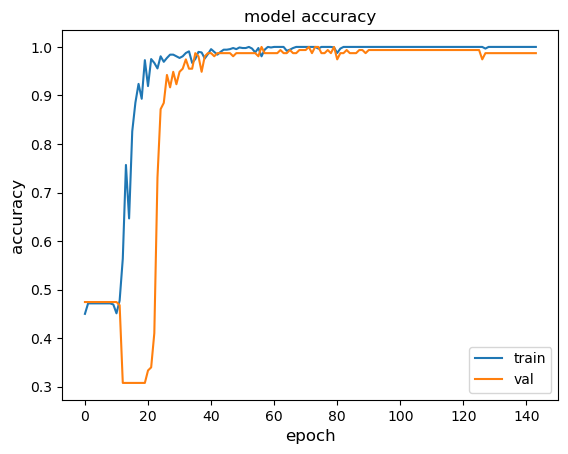

In [17]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()


## Evaluation

Load test set (holdout, different from validation set)

In [18]:
#Select sensor csv folder:

# Create and display a FileChooser widget
fc_test = FileChooser('./')
fc_test.show_only_dirs=True
print("------------------------------\nSELECT TEST DATA SENSOR FOLDER\n------------------------------")
display(fc_test)
print("------------------------------\n")

------------------------------
SELECT TEST DATA SENSOR FOLDER
------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

------------------------------



Number of samples: 614
Sample size: 400
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 2
Shape of the data is: (399, 3)


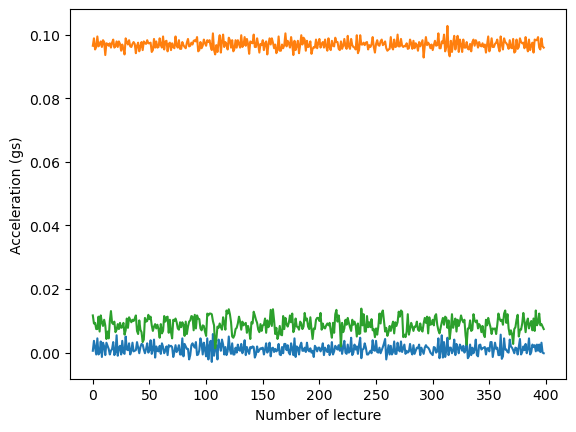

In [19]:
if fc_test.selected_path==None:
    print("No folder specified!! Using validation data as test data...")
    TestDataX=X_test
    TestDataY=y_test
else:
    full_path_test = fc_test.selected_path

    Current_file_path_test = os.path.join(full_path_test,os.listdir(full_path_test)[0])

    Current_file_test = open(Current_file_path_test) # Open first file for counting rows

    num_samples_test= len(os.listdir(full_path_test)) #number of .csv files in total
    tam_samples_test= len(Current_file_test.readlines())#number of lectures in a window sample (rows in each .csv)
    num_features_test = 3 #axis number (3 for accel) TODO: read column number from the file

    print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples_test,tam_samples_test,num_features_test))
    print("-----------------------\nPlot example for first file:\n-----------------------")

    file_class_test=int(Current_file_path_test[-6:-4])-1 # Class is in the filename, at the end, just before file extension
    print("The class for this file is {}".format(file_class_test))

    plot_record(Current_file_path_test, 'Number of lecture', 'Acceleration (gs)')

    Current_file_test.close() # Close file
    
    TestDataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
    TestDataY=np.empty([num_samples])

    for i in range (num_samples):
        Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
        Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
        TestDataX[i]=Current_CSV

        file_class=int(Current_file_path[-6:-4])
        TestDataY[i]=file_class-1 #first class is class 1, but now we start from 0

    TestDataY = to_categorical(TestDataY)
    
    if np.any(np.isnan(DataX)):
        print("DANGER!! NaN values found in DataX!!")
    
    if np.any(np.isnan(DataY)):
        print("DANGER!! NaN values found in DataY!!")
    

### Predictions made from test (holdout) data

In [20]:
#Select model:

# Create and display a FileChooser widget
fc_model = FileChooser('./')
#fc_test.show_only_dirs=False
print("------------------------------\nSELECT TRAINED MODEL\n------------------------------")
display(fc_model)
print("------------------------------\n")

------------------------------
SELECT TRAINED MODEL
------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

------------------------------



In [21]:
if fc_model.selected_path==None:
    print("No model specified!!")
    #model = tf.keras.models.load_model(os.path.join(sensor_model_folder, best_model_lstm_name))
else:
    model = tf.keras.models.load_model(fc_model.selected)
    pred = model.predict(TestDataX)
    print("--------\nDone!")

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /

#### To confusion matrix

In [22]:
y_pred = np.argmax(pred, axis = 1)
#y_pred = to_categorical(y_pred) 
y_pred

array([2, 2, 2, ..., 2, 2, 2], dtype=int64)

In [23]:
p = sklearn.metrics.confusion_matrix(TestDataY.argmax(axis=1), y_pred, labels=[0,1,2])
p

array([[322,   0,   0],
       [  0, 223,   2],
       [  0,   0, 489]], dtype=int64)

In [24]:
p_norm = sklearn.metrics.confusion_matrix(TestDataY.argmax(axis=1), y_pred, labels=[0,1,2], normalize='true')
p_norm

array([[1.   , 0.   , 0.   ],
       [0.   , 0.991, 0.009],
       [0.   , 0.   , 1.   ]])

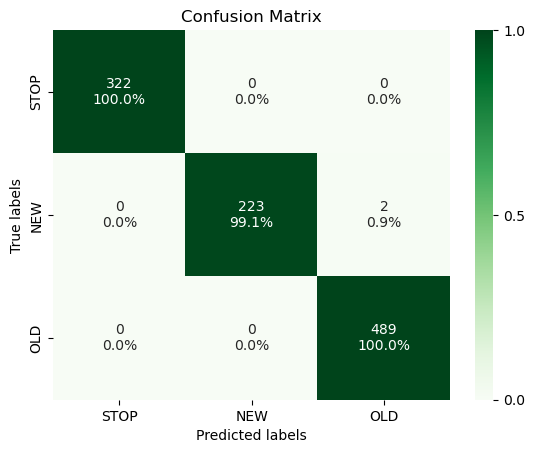

In [25]:
import seaborn as sns

T_lables = ['STOP','NEW','OLD']    

ax= plt.subplot()

# Set values format
values = ["{0:0.0f}".format(x) for x in p.flatten()]

# Find percentages and set format
percentages = ["{0:.1%}".format(x) for x in p_norm.flatten()]

# Combine classes, values and percentages to show 
combined = [f"{i}\n{j}" for i, j in zip(values, percentages)]
combined = np.asarray(combined).reshape(3,3)

sns.heatmap(p_norm, annot=combined, fmt='', ax=ax, cmap="Greens", cbar_kws={"ticks":[0,0.5,1], "format":'%.1f'});  #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(T_lables); ax.yaxis.set_ticklabels(T_lables);

#### More metrics

In [27]:
print(sklearn.metrics.classification_report(TestDataY.argmax(axis=1), y_pred, target_names=['STOP','NEW', 'OLD']))

              precision    recall  f1-score   support

        STOP       1.00      1.00      1.00       322
         NEW       1.00      0.99      1.00       225
         OLD       1.00      1.00      1.00       489

    accuracy                           1.00      1036
   macro avg       1.00      1.00      1.00      1036
weighted avg       1.00      1.00      1.00      1036



---
## Data plot

In [ ]:
# TO DO: METRICS AND PLOT CODE

In [ ]:
# TO DO: METRICS AND PLOT CODE